In [1]:
import pandas as pd
import numpy as np
from numpy import polyfit

import xarray as xr

import matplotlib.pyplot as plt

from bluemath_tk.tcs.tracks import get_category

* Data access can be requested to bluemath@unican.es
You can update any path or add new paths with the update_paths function, from bluemath_tk.config.paths.
Example: update_paths({'SHYTCWAVES_COEFS': '/new/path/to/data'})


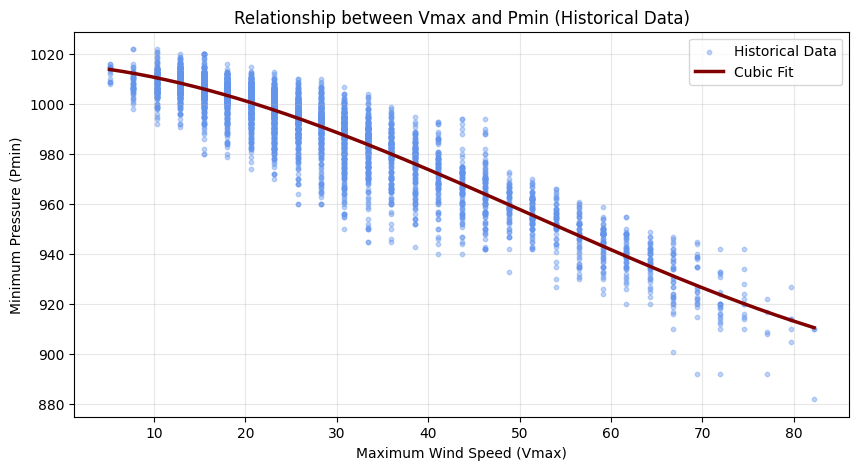

In [2]:
#### From wind to pres
hist_tracks_nc = xr.open_dataset('/lustre/geocean/WORK/users/alonsoap/personal/MUSCLE_TCS_NC/outputs/tracks_at_7r/hist_tracks_7r_filter.nc')
synth_tracks_nc = xr.open_dataset('/lustre/geocean/WORK/users/alonsoap/personal/MUSCLE_TCS_NC/outputs/tracks_at_7r/synth_tracks_7r_filter.nc')
hist_params_nc = xr.open_dataset('/lustre/geocean/WORK/users/alonsoap/personal/MUSCLE_TCS_NC/outputs/tracks_at_7r/hist_tracks_7r_params.nc')
synth_params_nc = xr.open_dataset('/lustre/geocean/WORK/users/alonsoap/personal/MUSCLE_TCS_NC/outputs/tracks_at_7r/synth_tracks_7r_params.nc')

df_hist_wind_pres = pd.DataFrame()
df_hist_wind_pres['wind'] = hist_tracks_nc['wmo_wind'].values.flatten() * 0.514
df_hist_wind_pres['pres'] = hist_tracks_nc['wmo_pres'].values.flatten()
df_hist_wind_pres = df_hist_wind_pres.dropna()

coeff_fit = polyfit(df_hist_wind_pres['wind'], df_hist_wind_pres['pres'], deg = 3)

pfit_pres = np.poly1d(coeff_fit)
x_fit = np.linspace(df_hist_wind_pres['wind'].min(), df_hist_wind_pres['wind'].max(), 200)
y_fit = pfit_pres(x_fit)

plt.figure(figsize=(10,5))
plt.scatter(df_hist_wind_pres['wind'], df_hist_wind_pres['pres'], 
            s=10, color = 'cornflowerblue', alpha=0.4, label='Historical Data')
plt.plot(x_fit, y_fit, color='maroon', linewidth=2.5, label='Cubic Fit')

plt.xlabel('Maximum Wind Speed (Vmax)')
plt.ylabel('Minimum Pressure (Pmin)')
plt.title('Relationship between Vmax and Pmin (Historical Data)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [3]:
#### User inputs
models = ['ec_earth3_veg_lr'] 
scenarios = ['historical', 'ssp245', 'ssp585']

p_min_trks = {}

for model in models:
    for ssp in scenarios:

        p_min_trks[(model, ssp)] = []

        simulated_daily_bmus = xr.open_dataset(f'outputs/tc_logit/{model}/{ssp}/simulated_tracktypes_with_tc_id_{model}_{ssp}.nc')
        emu_tracks = xr.open_dataset(f'outputs/tc_logit/{model}/{ssp}/emu_tracks_{model}_{ssp}.nc')

        vmax = emu_tracks['vmax_trks']

        pmin = xr.DataArray(
            pfit_pres(vmax.values),
            dims=vmax.dims,
            coords=vmax.coords,
            name='pmin_trks'
        )

        emu_tracks['pmin_trks'] = pmin

        for track in emu_tracks.storm_number.values:
            track_pmin = emu_tracks['pmin_trks'].sel(storm_number=track).values
            max_intensity = np.nanmin(track_pmin)
            p_min_trks[(model, ssp)].append(max_intensity)

        if ssp == 'historical':
            emu_tracks.to_netcdf(
                f'outputs/tc_logit/{model}/{ssp}/emu_tracks_{model}_{ssp}_corrected.nc'
            )

In [4]:
category_counts = {}

for model in models:
    for ssp in scenarios:
        p_min_list = p_min_trks[(model, ssp)]
        category_counts[(model, ssp)] = get_category(np.array(p_min_list))

category_counts_norm = {}
for model in models:
    for ssp in scenarios:
        counts = category_counts[(model, ssp)]
        cat, n_cat = np.unique(counts, return_counts=True)
        category_counts_norm[(model, ssp)] = n_cat / np.sum(n_cat)

In [5]:
df = pd.DataFrame(
    {k[1]: v for k, v in category_counts_norm.items()}
).T

df.columns = [f"bin_{i}" for i in range(df.shape[1])]
df.index.name = "scenario"

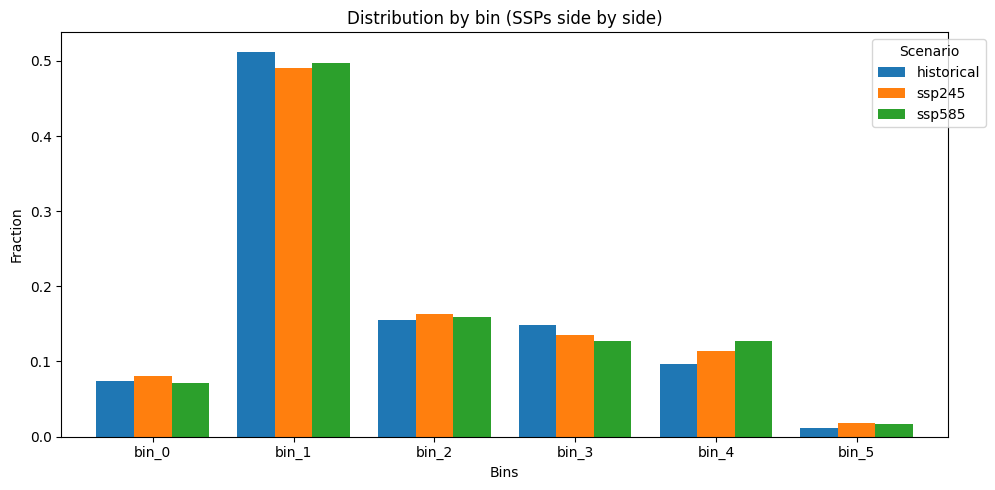

In [6]:
df_plot = df.T 

ax = df_plot.plot(
    kind="bar",
    figsize=(10,5),
    width=0.8
)

plt.title("Distribution by bin (SSPs side by side)")
plt.xlabel("Bins")
plt.ylabel("Fraction")
plt.xticks(rotation=0)
plt.legend(title="Scenario", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

In [7]:
df_plot

scenario,historical,ssp245,ssp585
bin_0,0.074542,0.079977,0.071883
bin_1,0.512424,0.490552,0.497031
bin_2,0.155601,0.163008,0.159457
bin_3,0.148676,0.135140,0.127014
bin_4,0.096945,0.113571,0.127651
bin_5,0.011813,0.017751,0.016964


In [8]:
#### Increments of Pressure
df_increments = pd.read_csv('inputs/change_in_intensity.csv')
df_increments.iloc[0] = df_increments.iloc[0] - df_increments.iloc[0,0]

In [9]:
df_increments

,historical,2k,4k
0,0.0,-0.97535,-2.2716


In [10]:
temp_evolution_per_ssp = pd.read_csv('inputs/temperature_increase/global-average-temperature-increase-relative-to-the-pre-industrial-era.csv')

In [11]:
ssp_keys = {'ssp245': 'SSP1 - Baseline', 'ssp585': 'SSP5 - Baseline'}

df_temp_evolution = pd.DataFrame()

for ssp in scenarios[1:]:
    temp_evolution_per_ssp[temp_evolution_per_ssp['Entity'] == ssp_keys[ssp]]
    df_temp_evolution[f'temp_{ssp}'] = temp_evolution_per_ssp[temp_evolution_per_ssp['Entity'] == ssp_keys[ssp]]['Temperature - Region: global'].values
    df_temp_evolution.index = temp_evolution_per_ssp[temp_evolution_per_ssp['Entity'] == ssp_keys[ssp]]['Year'].values

In [25]:
yearly_index = np.arange(2005, 2101)

df_temp_evolution_yearly = df_temp_evolution.reindex(yearly_index)
df_temp_evolution_yearly = df_temp_evolution_yearly.interpolate(method='linear')

coeff_fit = polyfit([0,2,4], [0,df_increments['2k'].values[0],df_increments['4k'].values[0]], deg = 2)
pfit = np.poly1d(coeff_fit)

df_temp_evolution_yearly['delta_pres_ssp245'] = pfit(df_temp_evolution_yearly['temp_ssp245'])
df_temp_evolution_yearly['delta_pres_ssp585'] = pfit(df_temp_evolution_yearly['temp_ssp585'])

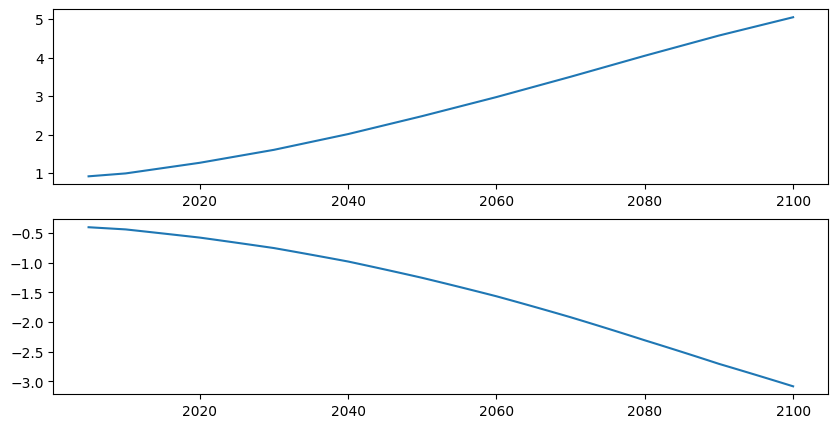

In [26]:
fig, axes = plt.subplots(2,1,figsize=(10,5))

axes[0].plot(df_temp_evolution_yearly.index, df_temp_evolution_yearly['temp_ssp585'], label='SSP2-4.5')
axes[1].plot(df_temp_evolution_yearly.index, df_temp_evolution_yearly['delta_pres_ssp585'], label='SSP5-8.5')

In [24]:
df_temp_evolution_yearly.loc[2080]

temp_ssp245          2.668723
temp_ssp585          4.049900
delta_pres_ssp245   -1.462084
delta_pres_ssp585   -2.246455
Name: 2080, dtype: float64

In [14]:
#### User inputs
models = ['ec_earth3_veg_lr'] 
scenarios = ['ssp245', 'ssp585']

p_min_trks = {}

for model in models:
    for ssp in scenarios:

        p_min_trks[(model, ssp)] = []

        simulated_daily_bmus = xr.open_dataset(f'outputs/tc_logit/{model}/{ssp}/simulated_tracktypes_with_tc_id_{model}_{ssp}.nc')
        emu_tracks = xr.open_dataset(f'outputs/tc_logit/{model}/{ssp}/emu_tracks_{model}_{ssp}.nc')

        vmax = emu_tracks['vmax_trks']

        pmin = xr.DataArray(
            pfit_pres(vmax.values),
            dims=vmax.dims,
            coords=vmax.coords,
            name='pmin_trks'
        )

        emu_tracks['pmin_trks'] = pmin

        adjusted = []

        for track in emu_tracks.storm_number.values:

            storm = emu_tracks.sel(storm_number=track)

            year = int(pd.to_datetime(storm.time_emulation.values).year)

            delta_pres = df_temp_evolution_yearly.loc[year, f'delta_pres_{ssp}']

            storm = storm.assign(
                pmin_trks=storm.pmin_trks + delta_pres
            )

            adjusted.append(storm)

        emu_tracks = xr.concat(adjusted, dim="storm_number")

        emu_tracks.to_netcdf(
            f'outputs/tc_logit/{model}/{ssp}/emu_tracks_{model}_{ssp}_corrected.nc'
        )

In [15]:
training_tracks = pd.read_csv('inputs/track_types_hist.csv')

In [16]:
training_tracks['pres'] = pfit_pres(training_tracks.vmax)

In [17]:
training_tracks['category'] = get_category(training_tracks['pres'].values)

In [18]:
training_tracks.to_csv('inputs/track_types_hist_with_cat.csv', index=False)

In [7]:
import xarray as xr

len(np.unique(xr.open_dataset('/lustre/geocean/WORK/users/alonsoap/personal/mini_projects/stochastic_gcms_clean_nc/outputs/tc_logit/ec_earth3_veg_lr/ssp245/emu_tracks_ec_earth3_veg_lr_ssp245_corrected.nc').storm_number.values))

5239

In [5]:
import numpy as np

len(np.unique(xr.open_dataset('/lustre/geocean/WORK/users/alonsoap/personal/mini_projects/stochastic_gcms_clean_nc/outputs/tc_logit/ec_earth3_veg_lr/ssp245/simulated_tracktypes_with_tc_id_ec_earth3_veg_lr_ssp245.nc').tc_id.values))

4649

In [11]:
xr.open_dataset('/lustre/geocean/WORK/users/alonsoap/personal/mini_projects/stochastic_gcms_clean_nc/outputs/tc_logit/ec_earth3_veg_lr/ssp245/emu_tracks_ec_earth3_veg_lr_ssp245_corrected.nc').time_emulation.values

array(['2015-08-15T00:00:00.000000000', '2015-08-19T00:00:00.000000000',
       '2015-09-04T00:00:00.000000000', ...,
       '2100-10-14T00:00:00.000000000', '2100-10-31T00:00:00.000000000',
       '2100-12-23T00:00:00.000000000'], dtype='datetime64[ns]')

In [ ]:
xr.open_dataset('/lustre/geocean/WORK/users/alonsoap/personal/mini_projects/stochastic_gcms_clean_nc/outputs/tc_logit/ec_earth3_veg_lr/historical/emu_tracks_ec_earth3_veg_lr_historical_corrected.nc').sim_number.values

<xarray.Dataset> Size: 73MB
Dimensions:            (storm_number: 2455, time: 361, basin: 7, month: 12)
Coordinates:
    year               (storm_number) int64 20kB ...
    storm              (storm_number) int64 20kB ...
  * time               (time) float64 3kB 0.0 3.6e+03 ... 1.292e+06 1.296e+06
  * basin              (basin) <U2 56B 'AU' 'EP' 'NA' 'NI' 'SI' 'SP' 'WP'
  * month              (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Dimensions without coordinates: storm_number
Data variables: (12/18)
    lon_trks           (storm_number, time) float64 7MB ...
    lat_trks           (storm_number, time) float64 7MB ...
    u250_trks          (storm_number, time) float64 7MB ...
    v250_trks          (storm_number, time) float64 7MB ...
    u850_trks          (storm_number, time) float64 7MB ...
    v850_trks          (storm_number, time) float64 7MB ...
    ...                 ...
    tc_days            (storm_number) float64 20kB ...
    seeds_per_month    (storm_number, basin, month) float64 2MB ...
    original_storm_id  (storm_number) int64 20kB ...
    time_emulation     (storm_number) datetime64[ns] 20kB ...
    sim_number         (storm_number) int64 20kB ...
    pmin_trks          (storm_number, time) float64 7MB ...

In [21]:
xr.open_dataset('/lustre/geocean/WORK/users/faugeree/projects/DUKE_carollinas_HyTcWaves/outputs/predicted_emu_tracks_ec_earth3_veg_lr_historical_corrected.nc')

<xarray.Dataset> Size: 3MB
Dimensions:   (case_num: 907, time: 24, point: 4)
Coordinates:
  * case_num  (case_num) int64 7kB 0 1 2 3 4 5 6 ... 900 901 902 903 904 905 906
  * time      (time) int64 192B 0 1 2 3 4 5 6 7 8 ... 15 16 17 18 19 20 21 22 23
  * point     (point) <U7 112B 'point_1' 'point_2' 'point_3' 'point_4'
Data variables:
    Hsig      (case_num, time, point) float64 697kB ...
    TPsmoo    (case_num, time, point) float64 697kB ...
    Windv_x   (case_num, time, point) float64 697kB ...
    Windv_y   (case_num, time, point) float64 697kB ...
    Dir       (case_num, time, point) float64 697kB ...

In [24]:
xr.open_dataset('/lustre/geocean/WORK/users/alonsoap/personal/mini_projects/stochastic_gcms_clean_nc/outputs/tc_logit/ec_earth3_veg_lr/historical/emu_tracks_ec_earth3_veg_lr_historical_corrected.nc')

<xarray.Dataset> Size: 73MB
Dimensions:            (storm_number: 2455, time: 361, basin: 7, month: 12)
Coordinates:
    year               (storm_number) int64 20kB ...
    storm              (storm_number) int64 20kB ...
  * time               (time) float64 3kB 0.0 3.6e+03 ... 1.292e+06 1.296e+06
  * basin              (basin) <U2 56B 'AU' 'EP' 'NA' 'NI' 'SI' 'SP' 'WP'
  * month              (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Dimensions without coordinates: storm_number
Data variables: (12/18)
    lon_trks           (storm_number, time) float64 7MB ...
    lat_trks           (storm_number, time) float64 7MB ...
    u250_trks          (storm_number, time) float64 7MB ...
    v250_trks          (storm_number, time) float64 7MB ...
    u850_trks          (storm_number, time) float64 7MB ...
    v850_trks          (storm_number, time) float64 7MB ...
    ...                 ...
    tc_days            (storm_number) float64 20kB ...
    seeds_per_month    (storm_number, basin, month) float64 2MB ...
    original_storm_id  (storm_number) int64 20kB ...
    time_emulation     (storm_number) datetime64[ns] 20kB ...
    sim_number         (storm_number) int64 20kB ...
    pmin_trks          (storm_number, time) float64 7MB ...